# TTE/TTF Algorithm Demonstration

This notebook demonstrates how to use the TTE/TTF calculator with NESS battery pack data.

**Key Concepts:**
- **EMA (Exponential Moving Average)**: 15-minute window smoothing for noisy current measurements
- **Base Load Profile**: Historical hourly patterns for low-current periods (idle/standby)
- **SOC Tracking**: Continuous State of Charge monitoring
- **TTE/TTF**: Time To Empty / Time To Full estimation with confidence levels

## Setup and Imports

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pytz

# Add utils to path
sys.path.insert(0, '../utils')
sys.path.insert(0, '../')

from tte_ttf_algorithm import (
    TTETTFCalculator,
    BatteryBaseLoadProfile,
    quick_tte,
    quick_ttf
)

from dto_classes import dto_ness_parquet


## 1. Load and Prepare Data

In [2]:
# Load sample data from parquet file
data_path = '../data/SE0100000092.parquet'

print(f"Loading data from: {data_path}")
df_raw = pd.read_parquet(data_path)

print(f"\nRaw data shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(f"\nFirst few rows:")
print(df_raw.head())

Loading data from: ../data/SE0100000092.parquet

Raw data shape: (995137, 41)
Columns: ['Vbus', 'Err', 'Tamb', 'SoC', 'Ip', 'SoH', 'Warn', 'Q', 'Vp', 'BalStat', 'CyCnt', 'HwErr', 'V1', 'FullCap', 'V2', 'V3', 'V4', 'BT1', 'V5', 'V6', 'BT3', 'V7', 'BT2', 'V8', 'V9', 'BT4', 'Tpow', 'DisconStat', 'BMSArrId', 'BPackID', 'MOSstate', 'V10', 'V12', 'V11', 'V14', 'V13', 'V16', 'V15', 'SysState', 'timestamp', 'entity_id']

First few rows:
    Vbus Err Tamb SoC    Ip  SoH Warn      Q     Vp BalStat  ...   V10   V12  \
0  52220   0  363  27  5570  100    0  20350  52150       0  ...  3267  3262   
1  52220   0  363  26  5570  100    0  20320  52150       0  ...  3267  3261   
2  52220   0  363  26  5600  100    0  20290  52150       0  ...  3267  3262   
3  52220   0  363  26  5570  100    0  20250  52150       0  ...  3267  3261   
4  52220   0  363  26  5590  100    0  20220  52150       0  ...  3267  3261   

    V11   V14   V13   V16   V15 SysState      timestamp entity_id  
0  3268  3264  326

In [3]:
# Use DTO to validate and transform data
dto = dto_ness_parquet(df_raw)
df = dto.df

print(f"Processed data shape: {df.shape}")
print(f"\nProcessed columns: {list(df.columns)}")
print(f"\nData info:")
print(df.info())

Processed data shape: (995137, 29)

Processed columns: ['ts', 'ic', 'id', 'lv', 'soc', 'tmp', 'soh', 'strv_1', 'strv_2', 'strv_3', 'strv_4', 'strv_5', 'strv_6', 'strv_7', 'strv_8', 'strv_9', 'strv_10', 'strv_11', 'strv_12', 'strv_13', 'strv_14', 'strv_15', 'strv_16', 'CyCnt', 'FullCap', 'BT1', 'BT2', 'BT3', 'BT4']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995137 entries, 0 to 995136
Data columns (total 29 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   ts       995137 non-null  float64
 1   ic       995137 non-null  float64
 2   id       995137 non-null  float64
 3   lv       995137 non-null  float64
 4   soc      995137 non-null  float64
 5   tmp      995137 non-null  float64
 6   soh      995137 non-null  float64
 7   strv_1   995137 non-null  float64
 8   strv_2   995137 non-null  float64
 9   strv_3   995137 non-null  float64
 10  strv_4   995137 non-null  float64
 11  strv_5   995137 non-null  float64
 12  strv_6   9

In [4]:
# Convert timestamp and add time columns
indian_time = pytz.timezone('Asia/Kolkata')

df['ts'] = pd.to_datetime(df['ts'], unit='ms', utc=True)
df['indian_time'] = df['ts'].dt.tz_convert(indian_time)

# Sort by timestamp
df = df.sort_values('ts').reset_index(drop=True)

print(f"Date range: {df['ts'].min()} to {df['ts'].max()}")
print(f"\nKey columns info:")
for col in ['ts', 'ic', 'id', 'soc', 'FullCap']:
    if col in df.columns:
        print(f"  {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, null={df[col].isnull().sum()}")

Date range: 2025-03-12 09:38:01.367000+00:00 to 2025-12-26 07:28:09.532000+00:00

Key columns info:
  ts: min=.2f, max=.2f, null=0
  ic: min=0.00, max=137910.00, null=0
  id: min=0.00, max=43990.00, null=0
  soc: min=0.00, max=108.00, null=0
  FullCap: min=100000.00, max=330920.00, null=0


## 2. Train Base Load Profile (Optional but Recommended)

In [5]:
# Create and train base load profile from available data
base_load_profile = BatteryBaseLoadProfile(min_samples_per_hour=3)
base_load_profile.train(df, current_col='id', charge_current_col='ic', timestamp_col='ts')

print("âœ“ Base Load Profile Training Complete")
print(f"\nHourly Base Load Profiles:")
print("Hour | Discharge (A) | Charge (A)")
print("-----|---------------|-----------")

for hour in range(24):
    if hour in base_load_profile.hourly_profiles:
        discharge = base_load_profile.hourly_profiles[hour]['discharge']
        charge = base_load_profile.hourly_profiles[hour]['charge']
        print(f"{hour:4d} | {discharge:13.3f} | {charge:9.3f}")

âœ“ Base Load Profile Training Complete

Hourly Base Load Profiles:
Hour | Discharge (A) | Charge (A)
-----|---------------|-----------
   0 |      3170.000 |  1170.000
   1 |      2420.000 |  2305.000
   2 |      1950.000 |  4760.000
   3 |      2130.000 | 11770.000
   4 |      2120.000 | 16410.000
   5 |      1880.000 | 16710.000
   6 |      1740.000 | 12920.000
   7 |      1810.000 |  9920.000
   8 |      2260.000 |  9120.000
   9 |      2380.000 |  6420.000
  10 |      2450.000 |  3480.000
  11 |      3660.000 |  2690.000
  12 |      6240.000 |  1560.000
  13 |      8410.000 |  5360.000
  14 |      8190.000 |  5670.000
  15 |      6430.000 |  6630.000
  16 |      4610.000 |  8565.000
  17 |      3530.000 |  7840.000
  18 |      3150.000 | 16700.000
  19 |      3040.000 |   895.000
  20 |      2730.000 | 13430.000
  21 |      2600.000 |  6270.000
  22 |      2570.000 |  6630.000
  23 |      2770.000 |   730.000


## 3. Initialize Calculator and Estimate TTE/TTF

In [6]:
# Create calculator with trained base load profile
calculator = TTETTFCalculator(
    base_load_profile=base_load_profile,
    current_threshold_ma=50.0,      # Switch to base load if current < 50mA
    ema_window_minutes=15            # 15-minute EMA window
)

print("âœ“ TTETTFCalculator initialized")
print(f"  - EMA Window: 15 minutes")
print(f"  - Current Threshold: 50 mA")
print(f"  - Base Load Profile: {'Enabled' if base_load_profile else 'Disabled'}")

âœ“ TTETTFCalculator initialized
  - EMA Window: 15 minutes
  - Current Threshold: 50 mA
  - Base Load Profile: Enabled


In [7]:
# Estimate TTE/TTF for entire dataset
results_df = calculator.estimate_batch(
    df,
    soc_col='soc',
    capacity_col='FullCap',
    discharge_current_col='id',
    charge_current_col='ic',
    timestamp_col='ts'
)

print(f"\nâœ“ TTE/TTF Calculation Complete")
print(f"Processed {len(results_df)} records")
print(f"\nResults preview:")
print(results_df.head(10))


âœ“ TTE/TTF Calculation Complete
Processed 995137 records

Results preview:
                         timestamp   soc  capacity_ah  ema_current_a  \
0 2025-03-12 09:38:01.367000+00:00  99.0        100.0       0.650000   
1 2025-03-12 09:38:19.478000+00:00  99.0        100.0       0.000000   
2 2025-03-12 09:38:37.604000+00:00  99.0        100.0       0.000000   
3 2025-03-12 09:39:09.827000+00:00  99.0        100.0       0.153750   
4 2025-03-12 09:39:27.953000+00:00  99.0        100.0       0.315781   
5 2025-03-12 09:39:46.082000+00:00  99.0        100.0       0.457559   
6 2025-03-12 09:40:04.211000+00:00  99.0        100.0       0.559114   
7 2025-03-12 09:40:32.408000+00:00  99.0        100.0       0.594225   
8 2025-03-12 09:40:50.535000+00:00  99.0        100.0       0.584946   
9 2025-03-12 09:41:08.649000+00:00  99.0        100.0       0.000000   

   effective_current_a  tte_ttf_hours tte_ttf_hhmmss confidence        state  \
0             0.650000     152.307692      152:18:

## 4. Analysis of Results

In [8]:
# Summary statistics
print("\n" + "="*70)
print("TTE/TTF ESTIMATION SUMMARY")
print("="*70)

print(f"\nState Distribution:")
state_counts = results_df['state'].value_counts()
for state, count in state_counts.items():
    pct = 100 * count / len(results_df)
    print(f"  {state:15s}: {count:6d} ({pct:5.1f}%)")

print(f"\nConfidence Distribution:")
conf_counts = results_df['confidence'].value_counts()
for conf, count in conf_counts.items():
    pct = 100 * count / len(results_df)
    print(f"  {conf:15s}: {count:6d} ({pct:5.1f}%)")

print(f"\nSOC Statistics:")
print(f"  Mean SOC: {results_df['soc'].mean():.2f}%")
print(f"  Min SOC:  {results_df['soc'].min():.2f}%")
print(f"  Max SOC:  {results_df['soc'].max():.2f}%")

print(f"\nCurrent Statistics:")
print(f"  Mean EMA Current: {results_df['ema_current_a'].mean():.3f} A")
print(f"  Max EMA Current:  {results_df['ema_current_a'].max():.3f} A")

# TTE/TTF for finite values
finite_times = results_df[results_df['tte_ttf_hours'] != float('inf')]
print(f"\nTTE/TTF Statistics (finite values, n={len(finite_times)}):")
print(f"  Mean Time: {finite_times['tte_ttf_hours'].mean():.2f} hours")
print(f"  Min Time:  {finite_times['tte_ttf_hours'].min():.2f} hours")
print(f"  Max Time:  {finite_times['tte_ttf_hours'].max():.2f} hours")


TTE/TTF ESTIMATION SUMMARY

State Distribution:
  discharging    : 584992 ( 58.8%)
  charging       : 252275 ( 25.4%)
  idle           : 157870 ( 15.9%)

Confidence Distribution:
  high           : 837260 ( 84.1%)
  low            : 157872 ( 15.9%)
  medium         :      5 (  0.0%)

SOC Statistics:
  Mean SOC: 53.06%
  Min SOC:  0.00%
  Max SOC:  108.00%

Current Statistics:
  Mean EMA Current: 5.340 A
  Max EMA Current:  45.770 A

TTE/TTF Statistics (finite values, n=837267):
  Mean Time: 18.40 hours
  Min Time:  -12.68 hours
  Max Time:  1980.00 hours


C:\Users\mishr\AppData\Local\Temp\ipykernel_285496\2671388269.py:71: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
e:\time_to_empty\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


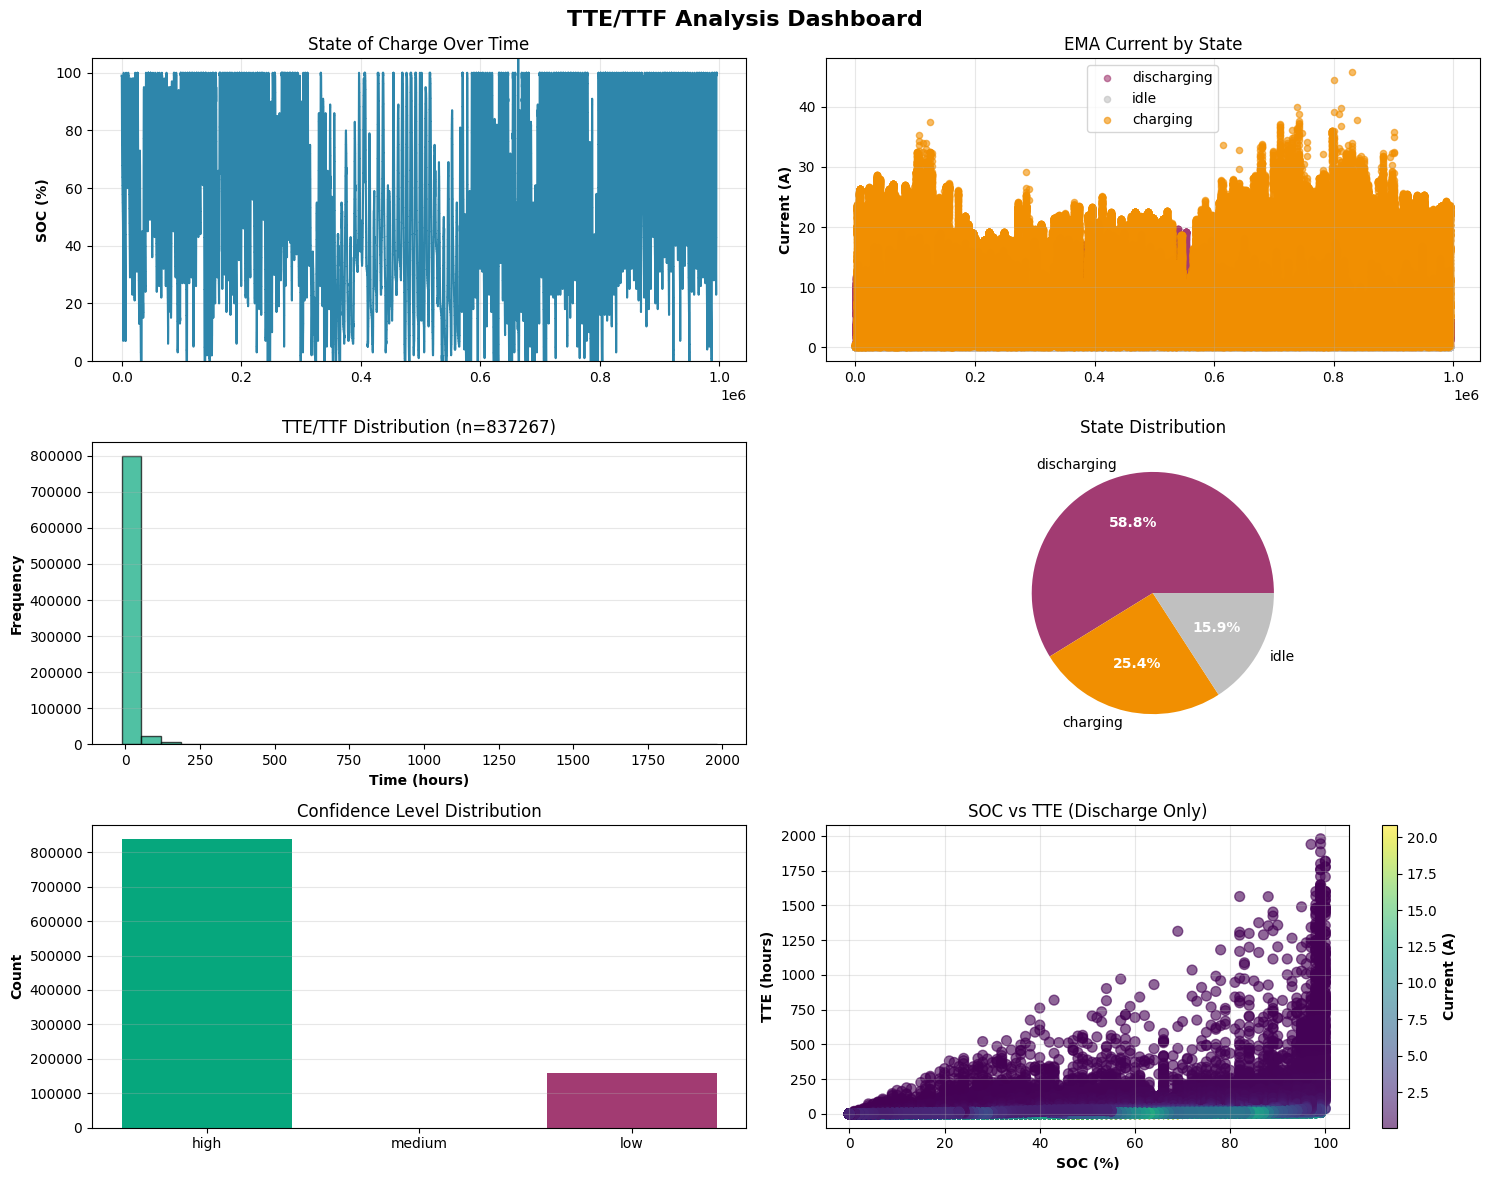


âœ“ Visualization complete


In [9]:
# Create visualizations
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('TTE/TTF Analysis Dashboard', fontsize=16, fontweight='bold')

# Plot 1: SOC over time
ax = axes[0, 0]
ax.plot(results_df.index, results_df['soc'], linewidth=1.5, color='#2E86AB')
ax.set_ylabel('SOC (%)', fontweight='bold')
ax.set_title('State of Charge Over Time')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 105])

# Plot 2: EMA Current over time
ax = axes[0, 1]
colors = {'discharging': '#A23B72', 'charging': '#F18F01', 'idle': '#C0C0C0'}
for state in results_df['state'].unique():
    mask = results_df['state'] == state
    ax.scatter(results_df[mask].index, results_df[mask]['ema_current_a'],
              label=state, s=20, alpha=0.6, color=colors.get(state, 'gray'))
ax.set_ylabel('Current (A)', fontweight='bold')
ax.set_title('EMA Current by State')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: TTE/TTF Distribution (finite values only)
ax = axes[1, 0]
finite_tte = results_df[results_df['tte_ttf_hours'] != float('inf')]['tte_ttf_hours']
ax.hist(finite_tte, bins=30, edgecolor='black', alpha=0.7, color='#06A77D')
ax.set_xlabel('Time (hours)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title(f'TTE/TTF Distribution (n={len(finite_tte)})')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: State Distribution
ax = axes[1, 1]
state_counts = results_df['state'].value_counts()
wedges, texts, autotexts = ax.pie(state_counts, labels=state_counts.index, autopct='%1.1f%%',
                                     colors=[colors.get(s, 'gray') for s in state_counts.index])
ax.set_title('State Distribution')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Plot 5: Confidence Distribution
ax = axes[2, 0]
conf_counts = results_df['confidence'].value_counts()
conf_order = ['high', 'medium', 'low']
conf_counts = conf_counts.reindex([c for c in conf_order if c in conf_counts.index])
colors_conf = {'high': '#06A77D', 'medium': '#F18F01', 'low': '#A23B72'}
bars = ax.bar(range(len(conf_counts)), conf_counts.values,
               color=[colors_conf.get(c, 'gray') for c in conf_counts.index])
ax.set_xticks(range(len(conf_counts)))
ax.set_xticklabels(conf_counts.index)
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Confidence Level Distribution')
ax.grid(True, alpha=0.3, axis='y')

# Plot 6: SOC vs TTE/TTF (discharge state only)
ax = axes[2, 1]
discharge_data = results_df[(results_df['state'] == 'discharging') & (results_df['tte_ttf_hours'] != float('inf'))]
if len(discharge_data) > 0:
    scatter = ax.scatter(discharge_data['soc'], discharge_data['tte_ttf_hours'],
                        c=discharge_data['ema_current_a'], cmap='viridis', s=50, alpha=0.6)
    ax.set_xlabel('SOC (%)', fontweight='bold')
    ax.set_ylabel('TTE (hours)', fontweight='bold')
    ax.set_title('SOC vs TTE (Discharge Only)')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Current (A)', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nâœ“ Visualization complete")

## 5. Quick Estimation Examples

In [10]:
# Example 1: Quick TTE without EMA
print("\n" + "="*70)
print("QUICK ESTIMATION EXAMPLES")
print("="*70)

# Scenario: 75% SOC, 50Ah capacity, 10A discharge
tte_quick = quick_tte(current_soc=75, capacity_ah=50, discharge_current_ma=10000)
print(f"\nScenario 1: Quick TTE Estimation")
print(f"  SOC: 75%, Capacity: 50 Ah, Current: 10 A")
print(f"  TTE = {tte_quick:.2f} hours")

# Scenario: 25% SOC, 50Ah capacity, 5A charge
ttf_quick = quick_ttf(current_soc=25, capacity_ah=50, charge_current_ma=5000)
print(f"\nScenario 2: Quick TTF Estimation")
print(f"  SOC: 25%, Capacity: 50 Ah, Current: 5 A")
print(f"  TTF = {ttf_quick:.2f} hours")


QUICK ESTIMATION EXAMPLES

Scenario 1: Quick TTE Estimation
  SOC: 75%, Capacity: 50 Ah, Current: 10 A
  TTE = 3.75 hours

Scenario 2: Quick TTF Estimation
  SOC: 25%, Capacity: 50 Ah, Current: 5 A
  TTF = 7.50 hours


## 6. Exporting Results

In [11]:
# Export results to CSV
output_path = '../outputs/tte_ttf_results.csv'
results_df.to_csv(output_path, index=False)

print(f"âœ“ Results exported to: {output_path}")
print(f"  Rows: {len(results_df)}")
print(f"  Columns: {', '.join(results_df.columns)}")

âœ“ Results exported to: ../outputs/tte_ttf_results.csv
  Rows: 995137
  Columns: timestamp, soc, capacity_ah, ema_current_a, effective_current_a, tte_ttf_hours, tte_ttf_hhmmss, confidence, state, num_samples


## 7. Key Insights & Recommendations

In [12]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

# Identify critical discharge periods
discharge_data = results_df[results_df['state'] == 'discharging']
if len(discharge_data) > 0:
    critical_low = discharge_data[discharge_data['soc'] < 20]
    print(f"\n1. Critical Low SOC Periods:")
    print(f"   Records with SOC < 20%: {len(critical_low)}")
    if len(critical_low) > 0:
        print(f"   Average TTE at low SOC: {critical_low[critical_low['tte_ttf_hours'] != float('inf')]['tte_ttf_hours'].mean():.2f} hours")

# Identify high current periods
high_current = results_df[results_df['ema_current_a'] > results_df['ema_current_a'].quantile(0.75)]
print(f"\n2. High Current Periods (75th percentile):")
print(f"   Average current threshold: {results_df['ema_current_a'].quantile(0.75):.3f} A")
print(f"   Number of high-current records: {len(high_current)}")
print(f"   Average TTE during high current: {high_current[high_current['state'] == 'discharging'][high_current['tte_ttf_hours'] != float('inf')]['tte_ttf_hours'].mean():.2f} hours")

# Confidence analysis
high_conf = results_df[results_df['confidence'] == 'high']
print(f"\n3. Estimation Confidence:")
print(f"   High confidence records: {len(high_conf)} ({100*len(high_conf)/len(results_df):.1f}%)")
print(f"   Minimum samples for high confidence: 10 measurements")

print(f"\n4. Algorithm Parameters (Current):")
print(f"   - EMA Window: 15 minutes")
print(f"   - Current Threshold: 50 mA (for base load switching)")
print(f"   - Base Load: {'Trained from {:.0f} records'.format(len(df))}")

print(f"\n5. Recommendations:")
print(f"   âœ“ Use HHMMSS format output for user-facing estimates")
print(f"   âœ“ Filter results by 'high' confidence for critical decisions")
print(f"   âœ“ Monitor SOC-based warnings at < 20% for discharge")
print(f"   âœ“ Retrain base load profile periodically with new data")


KEY INSIGHTS

1. Critical Low SOC Periods:
   Records with SOC < 20%: 77958
   Average TTE at low SOC: 7.32 hours

2. High Current Periods (75th percentile):
   Average current threshold: 7.353 A
   Number of high-current records: 248784
   Average TTE during high current: 6.50 hours

3. Estimation Confidence:
   High confidence records: 837260 (84.1%)
   Minimum samples for high confidence: 10 measurements

4. Algorithm Parameters (Current):
   - EMA Window: 15 minutes
   - Current Threshold: 50 mA (for base load switching)
   - Base Load: Trained from 995137 records

5. Recommendations:
   âœ“ Use HHMMSS format output for user-facing estimates
   âœ“ Filter results by 'high' confidence for critical decisions
   âœ“ Monitor SOC-based warnings at < 20% for discharge
   âœ“ Retrain base load profile periodically with new data


C:\Users\mishr\AppData\Local\Temp\ipykernel_285496\3925487681.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f"   Average TTE during high current: {high_current[high_current['state'] == 'discharging'][high_current['tte_ttf_hours'] != float('inf')]['tte_ttf_hours'].mean():.2f} hours")
